# Activation Functions

1. **What is an activation function ?**
- Activation functions are mathematical operations applied to the output of a neuron in an artificial neural network, deciding whether the neuron "fires" by transforming the weighted sum of inputs plus with bias
- An activation function takes the neuron's input i.e a linear combination of weights, inputs, and bias , and produces an output passed to the next layer
2. **What is the need of activation function in a neural network ?**
- To add non-linearity to the network , without non linear activation function no matter how many layers we consider , we cannot build complex decision boundary
3. **What are popular activation functions ?**
- Step function and Signed function [Non Differentiable]
- sigmoid
- tanh
- relu
- leaky-relu
- parametric-relu
- swish function
- softmax

|Function|	Output Range|	Key Features|	Limitations|
|--------|-------------|-------------|------------|
|Sigmoid	|(0, 1)|	Smooth, interpretable as probability|	Saturates for large inputs → vanishing gradients|
|Tanh|	(-1, 1)|	Zero-centered, stronger gradients|	Still suffers from saturation|
|ReLU (Rectified Linear Unit)|	[0, ∞)|	Simple, fast, effective|	“Dying ReLU” problem — neurons stop firing|
|Leaky ReLU|	(-∞, ∞)|	Small slope for negatives prevents dying neurons|	May introduce noise|
|Parametric ReLU (PReLU)|	(-∞, ∞)|	Learns the negative slope|	Slightly higher computational cost|
Softplus|	(0, ∞)|	Smooth approximation to ReLU|	Computationally heavier|
ELU (Exponential Linear Unit)|	(-1, ∞)|	Reduces bias shift, smooth gradient|	Needs careful initialization|
GELU (Gaussian Error Linear Unit)|	(-∞, ∞)	|Smooth, stochastic activation used in transformers	|Computationally expensive|

---

#### Step function and Signed function
- Step functions and sign functions are early, simple activation functions used in neural networks, primarily for binary decisions but limited by non-differentiability
- Step function is used to solve logic gates(AND/OR)
- In step function based on a threshold value , if input x below threshold 0 otherwise 1 , `neuron fire or not ` can be decided on threshold value
- The sign function (sgn) outputs -1 for x<0, 0 for x=0, and +1 for x > 0 providing three states for signed outputs.
- Used for binary or multi class classification problem
- Because these both are not differentiable , blocking the gradient based learning in back propagation

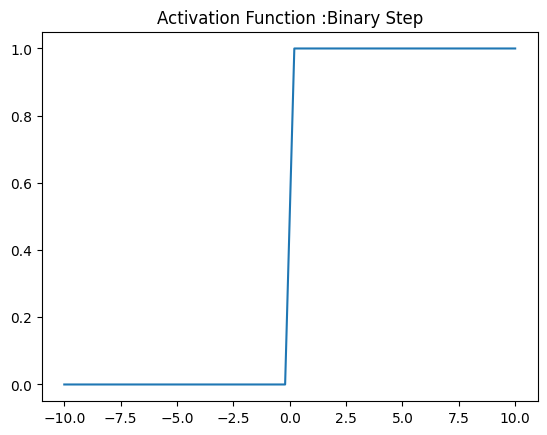

In [5]:
import numpy as np
import matplotlib.pyplot as plt
def binaryStep(x):
  '''It returns 'O' if the input is less then zero otherwise it returns one'''
  return np.heaviside(x,1)
x = np.linspace(-10, 10)
plt.plot(x, binaryStep(x))
plt.axis('tight')
plt.title('Activation Function :Binary Step')
plt. show()

---

#### Sigmoid function
- Sigmoid converts range -inf to inf -> 0 to 1 ,It is  Non linear function
$$
\sigma(z) = \frac{1}{1 + e^{-z}}
$$
- This function produces an **S-shaped (sigmoid) curve that smoothly squashes large negative inputs** close to 0 and large positive inputs close to 1.
- `Limitaions : `
  - `saturation`: Less expressiveness, There is no corresponding change in output for small change in inputs
  - `Vanishing Gradient` : The max value a numerical derivative can take is from 0 to 0.25
    - Whenever updating weights this gradient turns to be zero, there is no update weights , no change in the loss and we consider it as convergence
    - Poor solution is selected as best solution , Mainly predominant on initial layers

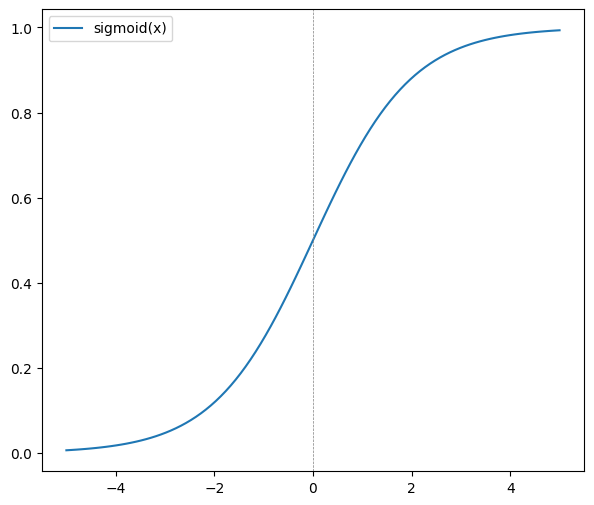

In [24]:
# activation function
def sigmoid(x): return 1. / (1. + np.exp(-x))
x = np.linspace(-5, 5, 100)
f = sigmoid
fx = f(x)

# Visualization
plt.figure(figsize=(7,6))
plt.plot(x, fx, label='sigmoid(x)')
plt.axvline(x=0, ls='--', lw=0.5, c='gray')
plt.legend()
plt.show()

---

#### tanh function
$$
\tanh(z) = \frac{\sinh(z)}{\cosh(z)} = \frac{e^{z} - e^{-z}}{e^{z} + e^{-z}}
$$
- Unlike the sigmoid function, which is asymmetric and ranges from 0 to 1, **tanh is symmetric around the origin and produces outputs between -1 and 1.** At z = 0, sigmoid yields 0.5 while tanh outputs 0, making it zero-centered and thus more suitable for hidden layers.

- For **large positive or negative values of z, tanh saturates at 1 or -1, causing its derivatives to become very small.** This leads to the vanishing gradient problem, where gradients approach zero and slow down learning in deep networks.

- Its **zero-centered output helps normalize activations, allowing faster convergence and more stable weight updates**—similar in spirit to data normalization in preprocessing.

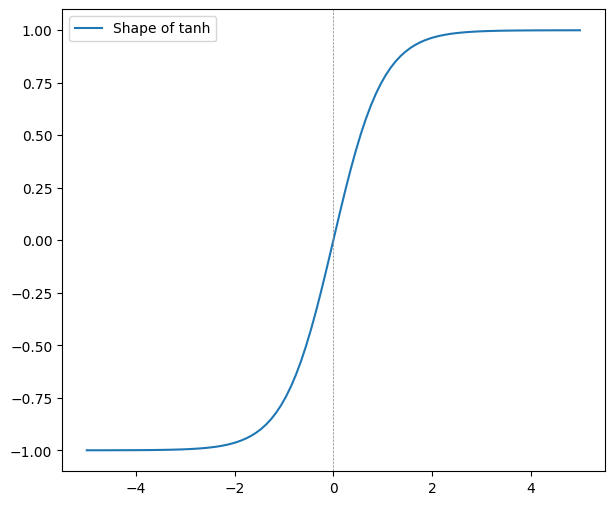

In [25]:
# activation function
def tanh(x): return np.tanh(x)

f = tanh
fx = f(x)
# Visualization
plt.figure(figsize=(7,6))
plt.plot(x, fx, label='Shape of tanh')
plt.axvline(x=0, ls='--', lw=0.5, c='gray')
plt.legend()
plt.show()

---

#### relu [rectified linear unit]
- `relu` is the first activation function that helps to overcome vanishing gradient
$$
\mathrm{ReLU}(z) = \max(0, z)
$$
- ReLU (Rectified Linear Unit) is a popular activation function defined as f(x)=max⁡(0,x) returns the input directly if positive and zero otherwise
- Its derivative is 1 for x > 0 and 0 for x < 0, avoiding vanishing gradients in positive regions.
- `Limitations : `
  - "Dying ReLU" where neurons stuck at zero stop learning; unbounded positive outputs can cause instability.

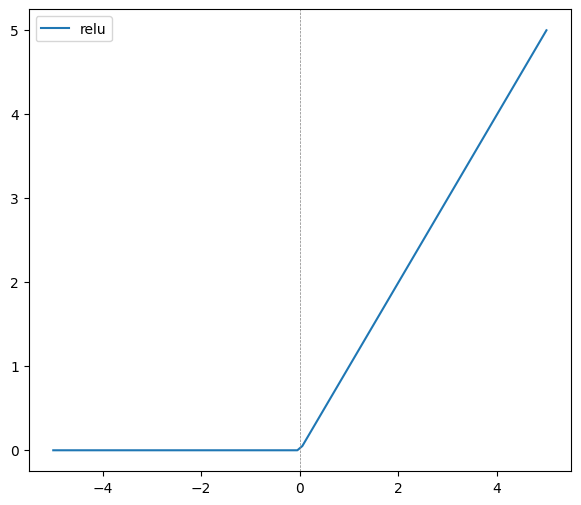

In [14]:
# activation function
def relu(x): return np.maximum(0, x)
# Visualization
plt.figure(figsize=(7,6))
plt.plot(x, fx, label='relu')
plt.axvline(x=0, ls='--', lw=0.5, c='gray')
plt.legend()
plt.show()

---

#### Leaky relu
While ReLU has become the default activation in deep neural networks due to its simplicity and computational efficiency, it is not without limitations.

- Its major drawback—the “dying ReLU” problem—occurs when neurons consistently receive negative inputs, causing their outputs and gradients to remain zero.
- These inactive neurons stop learning and contribute nothing to the network’s predictions.
- To address this issue, the Leaky ReLU (LReLU) introduces a small, non-zero slope for negative inputs instead of assigning them a flat zero. The function is defined as:

  $$
  f(z) =
  \begin{cases}
    z & \text{if } z \geq 0 \\
    \alpha z & \text{if } z < 0 \ \ (\alpha \ll 1)
  \end{cases}
  $$

where $0 < \alpha \ll 1$, typically $\alpha = 0.01$.

- This simple modification allows a small gradient to flow even when the neuron receives negative inputs, ensuring that no neuron completely “dies” during training.
- By maintaining non-zero gradients for all input ranges, Leaky ReLU helps mitigate both the vanishing gradient problem on the negative side and the dead neuron issue seen in standard ReLU.

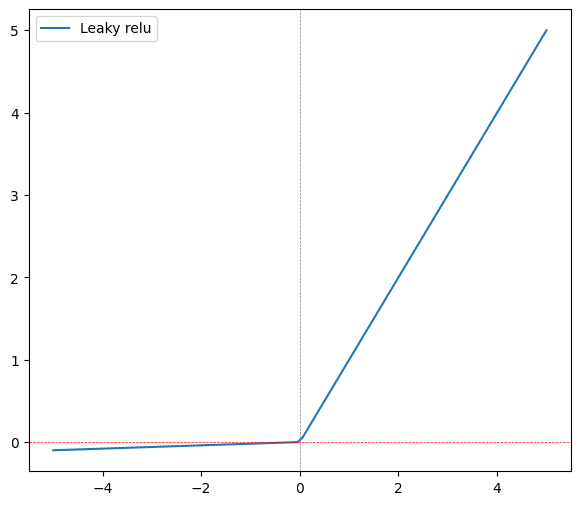

In [26]:
# activation function
def leaky_relu(x):
  alpha = 0.02
  return np.maximum(alpha*x, x)
x = np.linspace(-5, 5, 100)
# Visualization
plt.figure(figsize=(7,6))
plt.plot(x, leaky_relu(x), label='Leaky relu')
plt.axvline(x=0, ls='--', lw=0.5, c='gray')
plt.axhline(y=0, ls='--',lw = 0.5,c='red')
plt.legend()
plt.show()

- In implementation, Leaky ReLU is often expressed compactly as:
$$
f(z) = \max(\alpha z, z)
$$

---

#### Parametric RelU
The Parametric ReLU (PReLU) extends Leaky ReLU by **treating the negative slope $\alpha$ as a trainable parameter**, rather than a fixed constant. It is defined as:

$$
\text{PReLU}(x) =
\begin{cases}
x, & \text{if } x > 0 \\
\alpha x, & \text{if } x \leq 0
\end{cases}
$$

- In PReLU, the value of $\alpha$ is learned during training through backpropagation, similar to weights and biases. **This gives the model flexibility to automatically determine the optimal amount of “leakiness” for each neuron or layer.**
- **Advantages :**
- **Adaptive Learning:**
Each neuron can learn its own slope $\alpha$, enabling layer-wise or neuron-wise flexibility.
- **Enhanced Performance:**
Particularly beneficial when the optimal level of negative activation varies across different layers or features.

---

#### swish function
- swish function is the combination of ideas of sigmoid and relu
**Mathematical Definition**

Swish is mathematically expressed as:

$$
f(x) = x \cdot \sigma(\beta x)
$$

where:
- $x$ denotes the input to the neuron.
- $\sigma(x)$ is the sigmoid function defined as:
$$
\sigma(x) = \frac{1}{1 + e^{-x}}
$$

- $\beta$ serves as **a hyperparameter that governs the degree of smoothness and gating**.


When $\beta = 1$, the function represents the standard sigmoid activation; when $\beta$ is made trainable, it enables a more flexible and adaptive response across neurons and layers.
**Advantages :**
- **Self-gating behavior:** The sigmoid component acts as a gating mechanism, scaling the input adaptively. This allows Swish to smoothly interpolate between linear ($f(x) \approx x$ for large positive $x$) and suppressed ($f(x) \approx 0$ for large negative $x$) regions.
- **Learnable smoothness:** When $\beta$ is a trainable parameter, each neuron autonomously learns its optimal gating intensity, allowing for improved data-driven adaptability and representational flexibility.

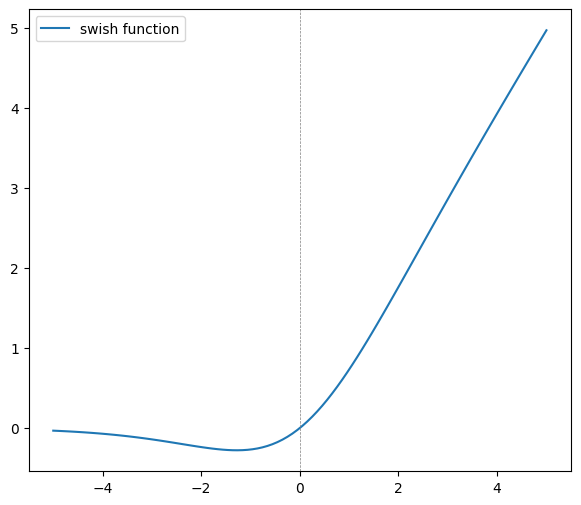

In [23]:
# activation function
def swish(x): return x*sigmoid(x)
x = np.linspace(-5, 5, 100)

f = swish
fx = f(x)

# Visualization
plt.figure(figsize=(7,6))
plt.plot(x, fx, label='swish function')
plt.axvline(x=0, ls='--', lw=0.5, c='gray')
plt.legend()
plt.show()